In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [2]:
# loading utility files

from utility.sv_fig import savefig
# from utility.mi_score import MI_score


In [3]:
# load data
train_data = pd.read_csv('data/Xy_NCa_Ca_md.csv')
test_data = pd.read_csv('data/Xy_test_NCa_Ca_md.csv')


In [4]:
all_col_names = train_data.columns.tolist()

print(all_col_names)

['ENA.78', 'IFN.y', 'IL.10', 'IL.6', 'IL.8', 'MCP.1', 'MDC', 'MIP.1a', 'TNF.a', 'C.peptide', 'G.CSF', 'IL.22', 'Insulin', 'Leptin', 'MIP.3a', 'GRO.a', 'HGF', 'MMP.2', 'Adiponectin', 'CRP', 'GDF.15', 'TIMP.1', 'TGF.B2', 'TGF.B1', 'PPAR.y', 'HIF.1a', 'Laminin', 'HbA1c', 'CA19.9', 'Glucose', 'HDL', 'CCK', 'LDL', 'Triglyceride', 'Albumin', 'Lumican', 'ZAG', 'CACHEXSTAGE0VIG']


In [5]:
# selected features: 'GDF.15', 'CRP', 'IL.22', 'Insulin', 'Albumin' 
train_data = train_data.drop(['ENA.78', 'IFN.y', 'IL.10', 'IL.6', 'IL.8', 'MCP.1', 'MDC', 'MIP.1a', 'TNF.a', 'C.peptide', 'G.CSF', 
                              'Leptin', 'MIP.3a', 'GRO.a', 'HGF', 'MMP.2', 'Adiponectin', 'TIMP.1', 'TGF.B2', 
                              'TGF.B1', 'PPAR.y', 'HIF.1a', 'Laminin', 'HbA1c', 'CA19.9', 'Glucose', 'HDL', 'CCK', 'LDL', 'Triglyceride', 
                              'Lumican', 'ZAG'], axis=1) # 0.80 / 0.20 RND_ST 1234



In [6]:

# Load your data
X = train_data.iloc[:,:-1]
y = train_data.iloc[:, -1] #.values

# Run analysis
analyzer = smpl_adeq.LearningCurveAnalyzer(X, y, task_type='classification')

    


Dataset Information:
  - Number of samples: 91
  - Number of features: 5
  - Task type: classification
  - Class distribution: {0.0: 19, 1.0: 72}



Generating learning curve for RBF-SVM...
Generating learning curve for Logistic Regression...
Generating learning curve for Random Forest...
Generating learning curve for Gradient Boosting...


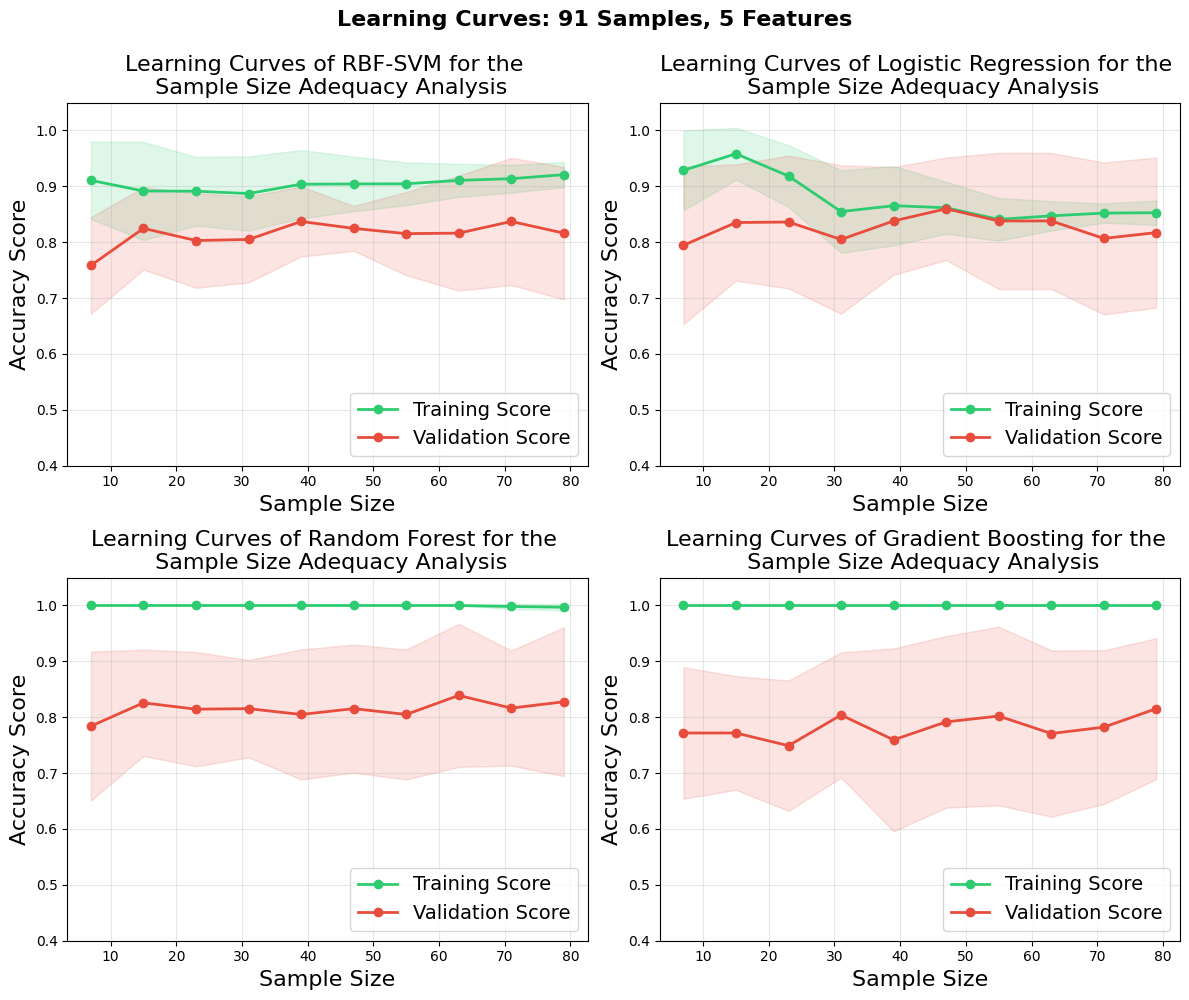

In [7]:

analyzer.generate_learning_curves()
analyzer.plot_learning_curves()

plt.tight_layout()

savefig('./figs/learning_curves_NCa_Ca_2',dpi=1200,quality=100)
